<a href="https://colab.research.google.com/github/Nemmoxida/Data-Science/blob/main/Praktikum_data_sci_sesi_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [4]:
df = pd.read_csv("/content/data_trans.csv")
df.head()

,ID_Transaksi,Warna_Tombol,Metode_Bayar,Waktu_Akses_Menit,Nominal_Transaksi
0,1,Biru,E-Wallet,5.2,150000
1,2,Hijau,Transfer Bank,12.5,250000
2,3,Biru,Kartu Kredit,3.1,350000
3,4,Hijau,E-Wallet,8.0,175000
4,5,Biru,E-Wallet,4.5,120000


In [7]:
df.describe()

,ID_Transaksi,Waktu_Akses_Menit,Nominal_Transaksi
count,20.00000,20.00000,20.000000
mean,10.50000,8.18500,231500.000000
std,5.91608,3.66897,91350.971533
min,1.00000,3.10000,120000.000000
25%,5.75000,5.15000,163750.000000
50%,10.50000,7.50000,200000.000000
75%,15.25000,10.97500,302500.000000
max,20.00000,15.20000,400000.000000


In [12]:
g_biru = df[df["Warna_Tombol"] == "Biru"]["Nominal_Transaksi"]
g_hijau = df[df["Warna_Tombol"] == "Hijau"]["Nominal_Transaksi"]

t_stat, p_value = stats.ttest_ind(g_biru, g_hijau)
print("t-statistic:", t_stat)
print("p-value:", p_value)

print()

if p_value < 0.05:
  print("Kesimpulan ditolak, ada perbedaan rata-rata nominal transaksi antara warna tombol biru dan hijau.")
else:
  print("Kesimpulan diterima, tidak ada perbedaan rata-rata nominal transaksi antara warna tombol biru dan hijau")

t-statistic: -1.3226598599988706
p-value: 0.202508039672407

Kesimpulan diterima, tidak ada perbedaan rata-rata nominal transaksi antara warna tombol biru dan hijau


In [20]:
ewallet = df[df["Metode_Bayar" ]== "E-Wallet"]["Nominal_Transaksi"]
transfer = df[df["Metode_Bayar" ]== "Transfer Bank"]["Nominal_Transaksi"]
kredit = df[df["Metode_Bayar" ]== "Kartu Kredit"]["Nominal_Transaksi"]

f_stat, p_val_anova = stats.f_oneway(ewallet, transfer, kredit)
print("F-statistic:", f_stat)
print("p-value:", p_val_anova)

print()

if p_val_anova < 0.05:
  print("Kesimpulan ditolak, ada perbedaan rata-rata nominal transaksi antara metode pembayaran E-Wallet, Transfer Bank, dan Kartu Kredit.")
else:
  print("Kesimpulan diterima, tidak ada perbedaan rata-rata nominal transaksi antara metode pembayaran E-Wallet, Transfer Bank, dan Kartu Kredit.")

F-statistic: 76.72152213188804
p-value: 3.0930855395370006e-09

Kesimpulan ditolak, ada perbedaan rata-rata nominal transaksi antara metode pembayaran E-Wallet, Transfer Bank, dan Kartu Kredit.


Correlation coefficient: 0.5555724975276234
p-value: 0.010983593554484866


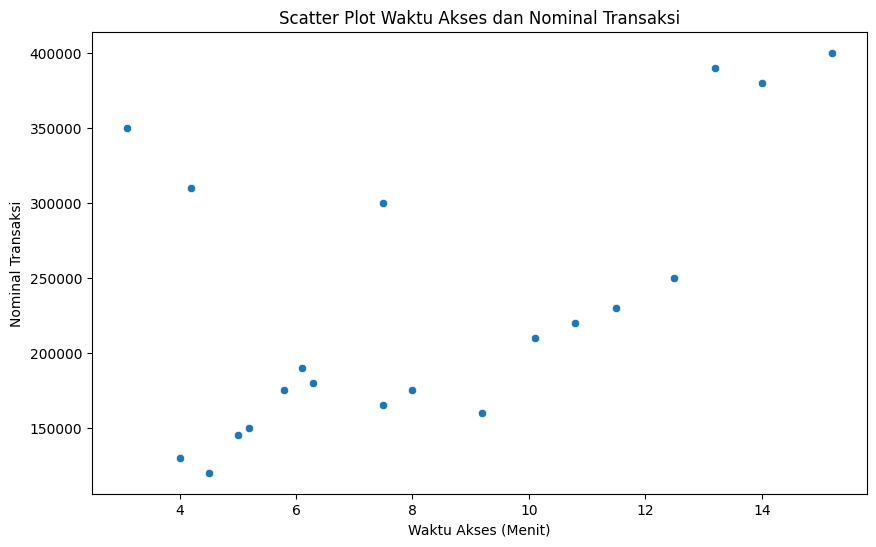

In [22]:
cor, p_val_cor = stats.pearsonr(df["Waktu_Akses_Menit"], df["Nominal_Transaksi"])
print("Correlation coefficient:", cor)
print("p-value:", p_val_cor)

plt.figure(figsize=(10, 6))
sns.scatterplot(x="Waktu_Akses_Menit", y="Nominal_Transaksi", data=df)
plt.title("Scatter Plot Waktu Akses dan Nominal Transaksi")
plt.xlabel("Waktu Akses (Menit)")
plt.ylabel("Nominal Transaksi")
plt.show()